In [1]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import pickle

run_idx = 8
with open(f"../stats/thm_solver_space_scheme_run_{run_idx}.pkl", "rb") as f:
    solver_space_scheme = pickle.load(f)

# Load permutations
with open(f"../stats/thm_permutations_{run_idx}.pkl", "rb") as f:
    permutations = pickle.load(f)
    permutations_inlet = permutations['inlet']
    permutations_outlet = permutations['outlet']


solver_space_scheme

{'block_type': 'LinearTransformedScheme',
 'scale_energy_balance': True,
 'Qright': True,
 'inner': {'block_type': 'PetscKSPScheme',
  'petsc_options': {'ksp_monitor': None,
   'ksp_rtol': 1e-12,
   'ksp_gmres_restart': NumericalChoices(None: [30 50])},
  'compute_eigenvalues': False,
  'preconditioner': {'block_type': 'PetscFieldSplitScheme',
   'groups': [0],
   'block_size': 3,
   'fieldsplit_options': {'pc_fieldsplit_schur_precondition': 'selfp'},
   'elim_options': {'pc_type': 'pbjacobi'},
   'keep_options': {'mat_schur_complement_ainv_type': 'blockdiag'},
   'complement': {'block_type': 'PetscFieldSplitScheme',
    'groups': [1, 2],
    'elim_options': {'pc_type': 'ilu'},
    'fieldsplit_options': {'pc_fieldsplit_schur_precondition': 'selfp'},
    'complement': {'block_type': 'PetscFieldSplitScheme',
     'groups': [3, 4],
     'elim_options': CategoricalChoices([{'pc_type': 'hypre', 'pc_hypre_type': 'boomeramg', 'pc_hypre_boomeramg_strong_threshold': NumericalChoices(None: [0.5 

In [3]:
solver_space = SolverSpace(
    solver_space_scheme=solver_space_scheme,
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = len(solver_space.all_decisions_encoding)
print(solver_space.decision_tree)
print("Num solvers:", num_solvers)

performance_predictor = PerformancePredictorPassiveAgressive(
    num_solvers=num_solvers,
)
solver_selector = SolverSelector(
    # reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)

block_type: LinearTransformedScheme
| ksp_gmres_restart: Choices from 30 to 50, len = 2
| elim_options (fork with 2 branches):
| | pc_type: hypre
| | | pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.9, len = 3
| | | pc_hypre_boomeramg_agg_nl: Choices from 0 to 2, len = 3
| | | pc_hypre_boomeramg_relax_type_all (fork with 4 branches):
| | | | symmetric-SOR/Jacobi
| | | | l1scaled-Jacobi
| | | | SOR/Jacobi
| | | | Jacobi
| | pc_type: gamg
| | | pc_gamg_threshold: Choices from -1.0 to 0.7, len = 5
| | | pc_gamg_agg_nsmooths: Choices from 1 to 2, len = 2
| | | pc_gamg_aggressive_coarsening: Choices from 1 to 2, len = 2
| block_type (fork with 2 branches):
| | block_type: PetscFieldSplitScheme
| | | elim_options (fork with 1 branches):
| | | | python_pc_type: hypre
| | | | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.9 to 0.9, len = 1
| | | | | python_pc_hypre_boomeramg_agg_nl: Choices from 2 to 2, len = 1
| | | | | python_pc_hypre_boomeramg_relax_type_all (fork 

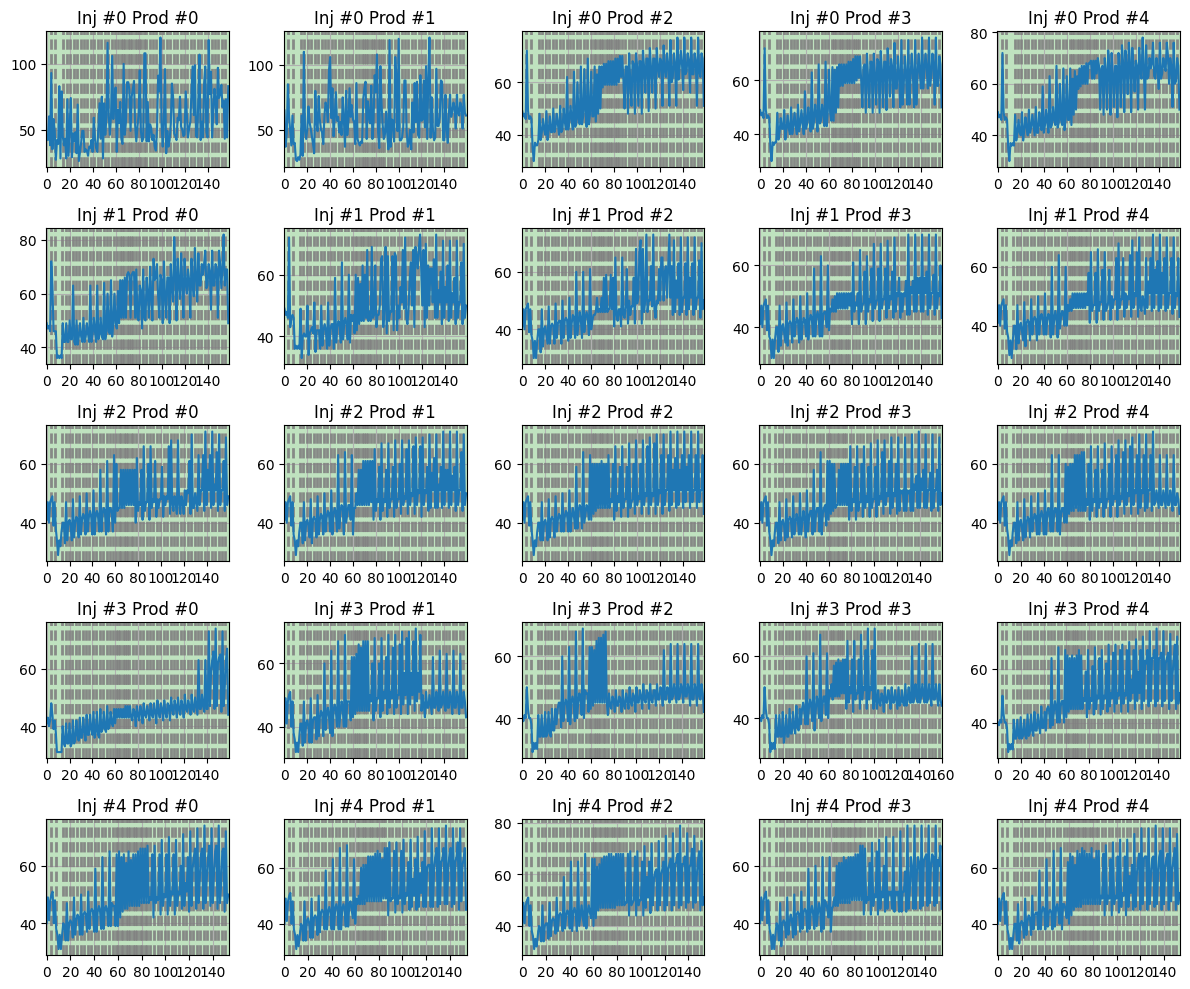

In [4]:
from itertools import count
from copy import copy
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
)
from solver_selection_thm.thm_runscript import inlet_placements, outlet_placements
from solver_selection_thm.thm_physics import simulation_name


data_simulations = []
solver_selection_history = []

inlet_placements = np.array(inlet_placements)
outlet_placements = np.array(outlet_placements)

RANDOM_SELECTION = False

for inlet_placement in inlet_placements[permutations_inlet]:
    data_row = []
    data_simulations.append(data_row)
    for outlet_placement in outlet_placements[permutations_outlet]:
        params["inlet_placement"] = inlet_placement
        params["outlet_placement"] = outlet_placement
        sim_name = f"run_{run_idx}_{simulation_name(params)}"
        if RANDOM_SELECTION:
            sim_name = f"RANDOM_{sim_name}"
        try:
            data = load_data(f"../stats/{sim_name}.json")
            data_row.append(data)
            solver_selector.history.load(f"../stats/solver_selection_history_{sim_name}.npy")
            solver_selection_history.append(copy(solver_selector.history))
        except FileNotFoundError:
            print('failed to load', sim_name)
            solver_selection_history.append(None)
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(inlet_placements), ncols=len(outlet_placements), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data)
        color_time_steps(data)
        st, sl, op = get_num_sticking_sliding_open(data)

        ax.plot(get_gmres_iterations(data))
        # ax.plot(st)
        # ax.plot(sl)
        # ax.plot(op)
        # ax.set_yscale('log')
        ax.set_title(f"Inj #{i} Prod #{j}")

plt.tight_layout()

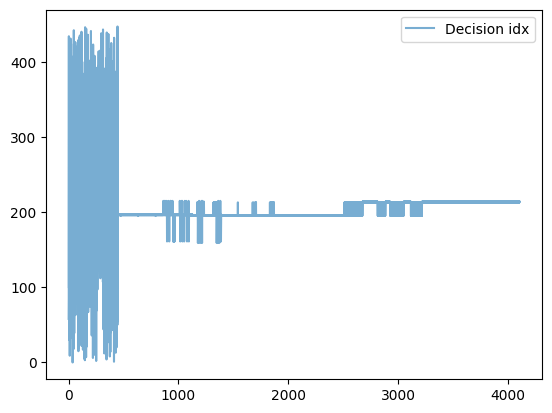

In [5]:
from solver_selection_thm.selector import SolverSelectorHistory
common_history: SolverSelectorHistory = solver_selection_history[-1]
# for x in solver_selection_history:
#     if x is None:
#         continue
#     common_history = x



decision_id = np.array(common_history.decision_idx)

# plt.plot(common_history.expectation, label='Expectation', alpha=0.6)
# plt.plot(common_history.reward, label='Reward', alpha=0.6)
plt.plot(common_history.decision_idx, label='Decision idx', alpha=0.6)

plt.legend()
# plt.ylim(-2, 0)

In [6]:
print(len(common_history.reward))
print(len(common_history.features))
print(np.unique(decision_id).size, num_solvers)


4107
4107
448 448


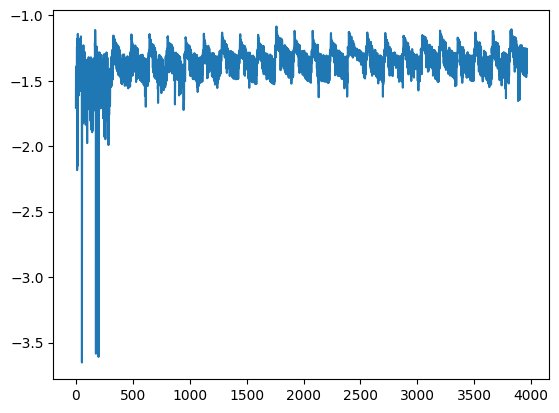

In [7]:
X, y = np.array(common_history.features), np.array(common_history.reward)

FAIL_REWARD = -100
# plt.plot(y)
success = y > FAIL_REWARD
plt.plot(y[success])

In [8]:
print(np.sum(success))
print(success.size)

3962
4107


## Can we classify to failed/not failed?

% success: 0.9646944241538836


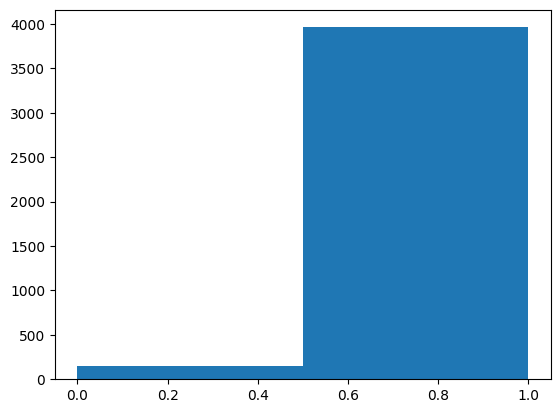

In [9]:
ycat = success[:]
plt.hist(ycat.astype(int), bins=2)

print("% success:", np.sum(ycat) / ycat.size)

In [10]:
from solver_selection_thm.solver_space import explain_decision

features_explained = [
                "dt",
                "temp_min",
                "temp_max",
                "cfl",
                "enthalpy_max",
                "enthalpy_mean",
                "fourier_max",
                "fourier_mean",
                "perm_estimate",
                'solver_reused',

] + [explain_decision(solver_space, i) for i in range(25)]

<BarContainer object of 35 artists>

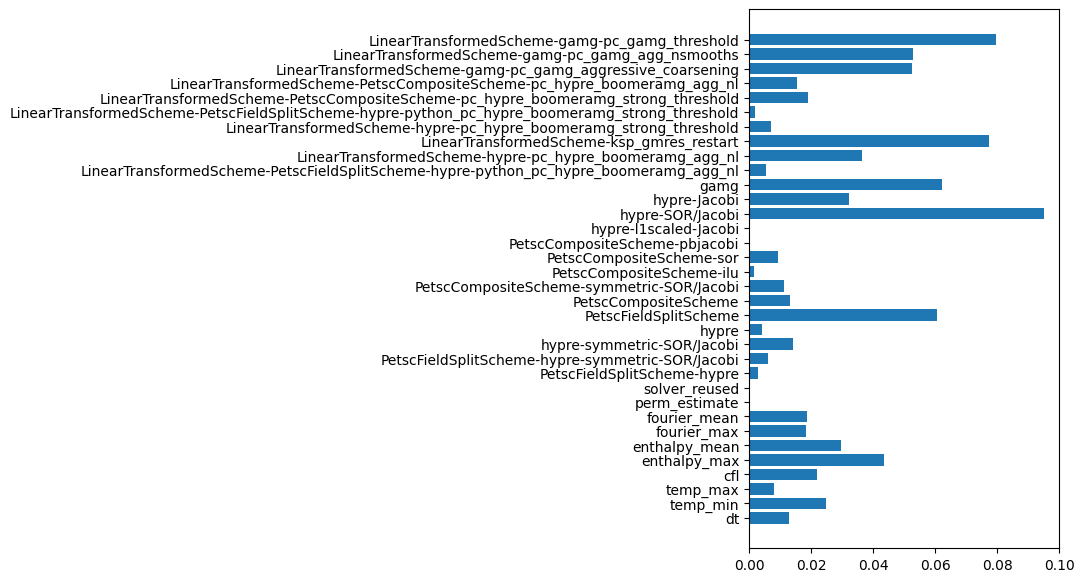

In [11]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(X), ycat, n_neighbors=10, random_state=42
)
plt.figure(figsize=(4, 7))
plt.barh(features_explained, mi)

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

cv_results = cross_validate(
    classifier,
    X,
    ycat,
    cv=5,
    scoring=("accuracy", "f1"),
    return_train_score=True,
    return_estimator=True,
)
print("Train Accuracy:", cv_results["train_accuracy"])
print("Test Accuracy:", cv_results["test_accuracy"])
print("Mean Train Accuracy:", np.mean(cv_results["train_accuracy"]))
print("Mean Test Accuracy:", np.mean(cv_results["test_accuracy"]))

print("Train F1:", cv_results["train_f1"])
print("Test F1:", cv_results["test_f1"])
print("Mean Train F1:", np.mean(cv_results["train_f1"]))
print("Mean Test F1:", np.mean(cv_results["test_f1"]))

best_classifier_offline = cv_results['estimator'][np.argmax(cv_results['test_f1'])]
best_classifier_offline

Train Accuracy: [1.         0.97442922 0.98021911 0.98508825 0.98630554]
Test Accuracy: [0.66545012 0.99513382 1.         0.99512789 0.99756395]
Mean Train Accuracy: 0.9852084253940196
Mean Test Accuracy: 0.9306551561652604
Train F1: [1.         0.9865686  0.98966778 0.99222592 0.99285147]
Test F1: [0.79023646 0.99747793 1.         0.99748111 0.99873897]
Mean Train F1: 0.9922627538098239
Mean Test F1: 0.9567868933771189


SuccessClassifier()

In [13]:
cv_results

{'fit_time': array([0.00717521, 0.02410746, 0.01365876, 0.01366878, 0.0159204 ]),
 'score_time': array([0.00307441, 0.00245214, 0.00229239, 0.0023694 , 0.00253248]),
 'estimator': [SuccessClassifier(),
  SuccessClassifier(),
  SuccessClassifier(),
  SuccessClassifier(),
  SuccessClassifier()],
 'test_accuracy': array([0.66545012, 0.99513382, 1.        , 0.99512789, 0.99756395]),
 'train_accuracy': array([1.        , 0.97442922, 0.98021911, 0.98508825, 0.98630554]),
 'test_f1': array([0.79023646, 0.99747793, 1.        , 0.99748111, 0.99873897]),
 'train_f1': array([1.        , 0.9865686 , 0.98966778, 0.99222592, 0.99285147])}

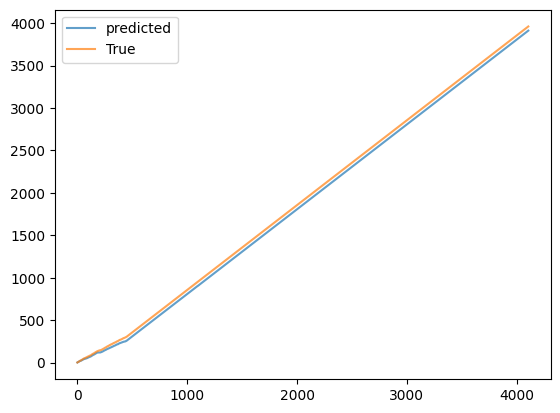

In [14]:
plt.plot(np.cumsum(best_classifier_offline.predict(X)), label='predicted', alpha=0.7)
# plt.plot(search.best_estimator_.predict(Xsuccess), label='predicted', alpha=0.7)
plt.plot(np.cumsum(ycat), label='True', alpha=0.7)
# plt.xlim(200, 400)
# plt.ylim(-2.5, 0)
plt.legend()

Split to xsuccess and xfail

In [15]:
Xsuccess = X[success]
ysuccess = y[success]
Xsuccess.shape

(3962, 35)

# In offline setting, how well does the data describe the target?
1. Estimating Mutual Information (MI)


<BarContainer object of 35 artists>

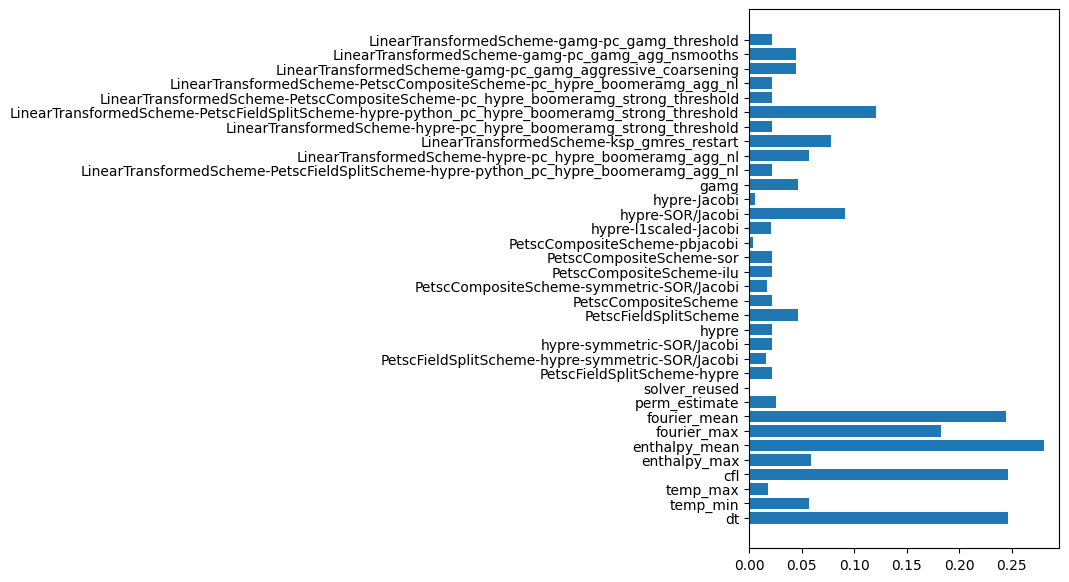

In [16]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(Xsuccess), ysuccess, n_neighbors=10, random_state=42
)
plt.figure(figsize=(4, 7))
plt.barh(features_explained, mi)

2. Training offline model with cross-validation and comparing its

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from solver_selection_thm.performance_predictor import RewardRegressor
from sklearn.base import RegressorMixin
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



# offline_pipeline = RewardRegressor()
# offline_pipeline = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
# offline_pipeline = make_pipeline(StandardScaler(), RandomForestRegressor(criterion='squared_error', random_state=42))
# offline_pipeline = RandomForestRegressor(criterion='squared_error', random_state=42)
offline_pipeline = GradientBoostingRegressor(criterion='squared_error', random_state=42)



# scoring = 'r2'
# scoring = 'neg_median_absolute_error'
scoring = 'neg_mean_absolute_error'
# scoring = 'neg_mean_squared_error'
# scoring = 'explained_variance'
cv_results = cross_validate(offline_pipeline, Xsuccess.clip(-1e10, 1e10), ysuccess, cv=5, scoring=scoring, return_train_score=True, return_estimator=True)
# cv_results = cross_validate(search.best_estimator_, Xsuccess, ysuccess, cv=5, scoring=scoring, return_train_score=True, return_estimator=True)


# Output
print("Train scores:", cv_results["train_score"])
print("Test scores:", cv_results["test_score"])
print("Mean Train :", np.mean(cv_results["train_score"]))
print("Mean Test :", np.mean(cv_results["test_score"]))

best_regressor_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_regressor_offline

Train scores: [-0.04211151 -0.04613584 -0.04684214 -0.04709025 -0.04505285]
Test scores: [-0.11920187 -0.04724852 -0.04922082 -0.04388275 -0.05299623]
Mean Train : -0.045446517733457856
Mean Test : -0.06251003935444957


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'squared_error'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [18]:
np.std(ysuccess)

0.13170089985920538

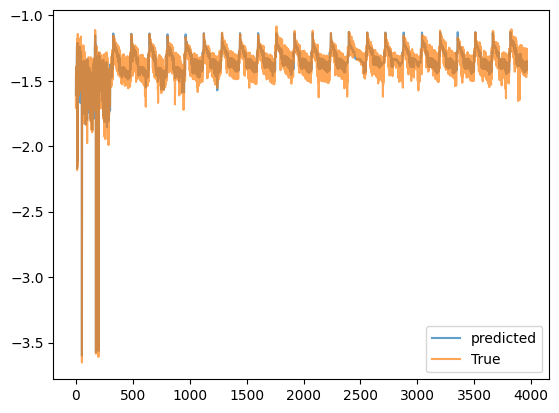

In [19]:
plt.plot(best_regressor_offline.predict(Xsuccess.clip(-1e10, 1e10)), label='predicted', alpha=0.7)
# plt.plot(search.best_estimator_.predict(Xsuccess), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
# plt.xlim(200, 400)
# plt.ylim(-2.5, 0)
plt.legend()

4. Now we treat them as classifiers. Offline - ground truth. How often does Online make different decisions? How much does this cost to it?

In [20]:
sep = num_solvers
Xoffline, yoffline = X[:sep], y[:sep]
Xonline, yonline = X[sep:], y[sep:]
print(Xoffline.shape, yoffline.shape, Xonline.shape, yonline.shape)

(448, 35) (448,) (3659, 35) (3659,)


In [21]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

In [22]:
from scipy.stats import spearmanr
import warnings
from scipy.stats import ConstantInputWarning

# warnings.filterwarnings("ignore", category=ConstantInputWarning)

def top1_score(ypred, ytrue):
    return np.argmax(ypred) == np.argmax(ytrue)

def topk_score(ypred, ytrue):
    top_k = 10
    return int(np.argmax(ytrue) in np.argsort(ypred)[-top_k:])

def top_1_normalized_score(ypred, ytrue):
    i = np.argmax(ypred)
    s = ytrue[i]
    ymin, ymax = np.min(ytrue), np.max(ytrue)
    if ymax == ymin:
        return 0.0  # degenerate case: all ytrue values are equal
    else:
        return -1.0 + 2.0 * (s - ymin) / (ymax - ymin)
    
def top_eps_accuracy(ypred, ytrue, eps=1e-3):
    i = np.argmax(ypred)
    return abs(ytrue[i] - np.max(ytrue)) <= eps

def rank_true_max(ypred, ytrue):
    rank = (-ypred).argsort().tolist().index(np.argmax(ytrue)) + 1
    return rank

def rank_spearman(ypred, ytrue):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConstantInputWarning)
        corr = spearmanr(ypred, ytrue).correlation
    if np.isnan(corr):
        # happens for constant array
        return 1.
    return corr

Offline ranking scoring

In [23]:
from sklearn.model_selection import KFold

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)

oracle = RandomForestRegressor(criterion='squared_error', random_state=42)
oracle.fit(Xsuccess.clip(-1e10, 1e10), ysuccess)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xsuccess_features = Xsuccess[:, : -all_solvers.shape[1]]  # removing solvers encoding

data_k_fold = []


for train_set, test_set in kf.split(Xsuccess):
    estimator = RewardRegressor()
    estimator.fit(Xsuccess[train_set], ysuccess[train_set])

    data_this = []
    data_k_fold.append(data_this)

    # ranking
    for test_idx in test_set:
        x_to_predict = stack_features_solvers(Xsuccess_features[test_idx], all_solvers)

        # online
        ypred = estimator.predict(x_to_predict)

        # offline
        yoracle = oracle.predict(x_to_predict.clip(-1e10, 1e10))

        data_this.append({'yoracle': yoracle, 'ypred': ypred})

In [24]:
mean_NTS = [np.mean([top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test]) for data_test in data_k_fold]
print(mean_NTS)
np.mean(mean_NTS)

[0.9019519072520593, 0.9045400486094408, 0.9043919692449732, 0.9077319143832467, 0.9054934116513117]


0.9048218502282064

In [136]:
eps = 1e-2
mean_topeps = [np.mean([top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_test]) for data_test in data_k_fold]
print(mean_topeps)
print(np.mean(mean_topeps))

[0.8310214375788146, 0.8158890290037831, 0.821969696969697, 0.8131313131313131, 0.8232323232323232]
0.8210487599831863


In [70]:
[np.mean([np.max(x['yoracle']) - np.max(x['ypred']) for x in data_test]) for data_test in data_k_fold]

[-0.057878119899196084,
 -0.03639359247554884,
 -0.05054782575461967,
 -0.04717689035910938,
 -0.03850448608704472]

Sanity check -- the predictor here does exactly the same result on the same data as in the real sim. (not true for `RANDOM_SELECTION`)

In [21]:
regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
regressor_online.fit(Xoffline, yoffline)

reward_expected = []

for Xbatch, ybatch in zip(Xonline, yonline):
    # online
    ypred_expected = regressor_online.predict(Xbatch.reshape(1, -1))

    # feedback
    solve_time = np.exp(-ybatch)
    regressor_online.partial_fit(Xbatch.reshape(1, -1), [ybatch])

    # saving stats
    reward_expected.append(ypred_expected.item())

if not RANDOM_SELECTION:
    assert np.allclose(reward_expected, common_history.expectation[num_solvers:], rtol=1e-10, atol=1e-10)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor


best_regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=RandomForestRegressor(criterion='squared_error', random_state=42))
# best_regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=KNeighborsRegressor())
best_regressor_offline.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding

regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
regressor_online.fit(Xoffline, yoffline)

decisions_online = []
decisions_offline = []
reward_offline = []
reward_online = []
reward_feedback = []
scores_top1 = []
scores_topk = []
scores_rank_true_max = []
scores_spearman = []
scores_top_eps = []
pred_online_list = []
pred_offline_list = []

for Xfeature in Xonline_features[:]:
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    max_score_online = predictions_online[max_score_idx_online]

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))
    max_score_idx_offline = np.argmax(predictions_offline)
    max_score_offline = predictions_offline[max_score_idx_offline]

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    regressor_online.partial_fit(X_feedback, [y_feedback])

    # saving stats
    decisions_offline.append(max_score_idx_offline)
    decisions_online.append(max_score_idx_online)
    reward_feedback.append(y_feedback)
    reward_offline.append(max_score_offline)
    reward_online.append(max_score_online)
    top1_score_ = top1_score(ypred=predictions_online, ytrue=predictions_offline)
    scores_top1.append(top1_score_)
    scores_topk.append(topk_score(ypred=predictions_online, ytrue=predictions_offline))
    rank_true_max_ = rank_true_max(ypred=predictions_online, ytrue=predictions_offline)
    scores_rank_true_max.append(rank_true_max_)
    rank_spearman_ = rank_spearman(ypred=predictions_online, ytrue=predictions_offline)
    scores_spearman.append(rank_spearman_)
    scores_top_eps.append(top_eps_score(ypred=predictions_online, ytrue=predictions_offline, eps=1e-6))
    pred_offline_list.append(predictions_offline)
    pred_online_list.append(predictions_online)

Metrics to evaluate the model:
- (maximize) mean spearman score
- (minimize) mean rank_true_max
- (minimize) num failures when expected success
- (minimize) for successful iterations, oracle reward for online decision minus oracle best reward (regret)
- (minimize) time for partial fit and evaluate (todo)

Mean top-eps score: 1.0


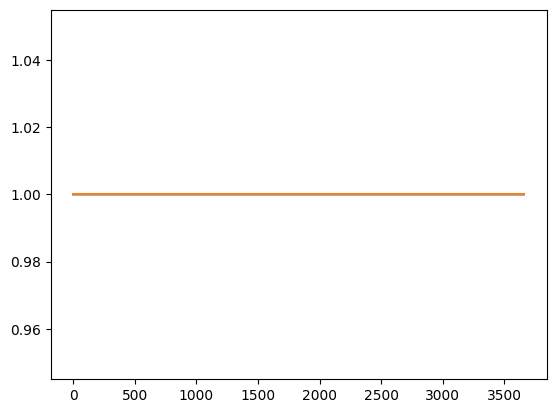

In [40]:
plt.plot(scores_top_eps)
mean = np.mean(scores_top_eps)
plt.plot([0, len(scores_top_eps)], [mean,mean])
print('Mean top-eps score:', mean)

Mean Spearman score: 1.0


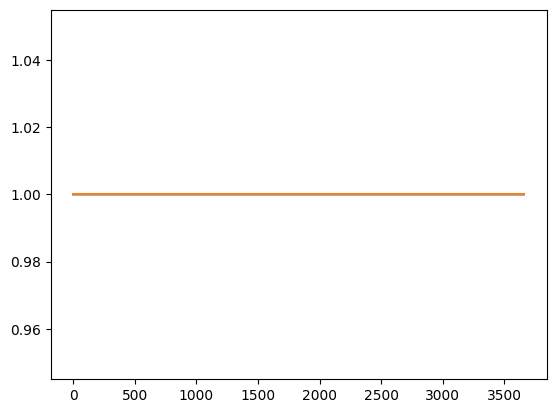

In [23]:
plt.plot(scores_spearman)
mean = np.mean(scores_spearman)
plt.plot([0, len(scores_rank_true_max)], [mean,mean])
print('Mean Spearman score:', mean)

Mean rank true max: 106.61000273298716


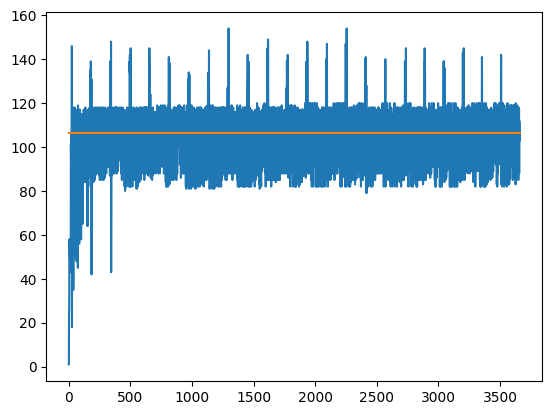

In [24]:
plt.plot(np.array(scores_rank_true_max))
mean = np.mean(scores_rank_true_max)
plt.plot([0, len(scores_rank_true_max)], [mean,mean])
print("Mean rank true max:", mean)

Num failures when expected success: 3657


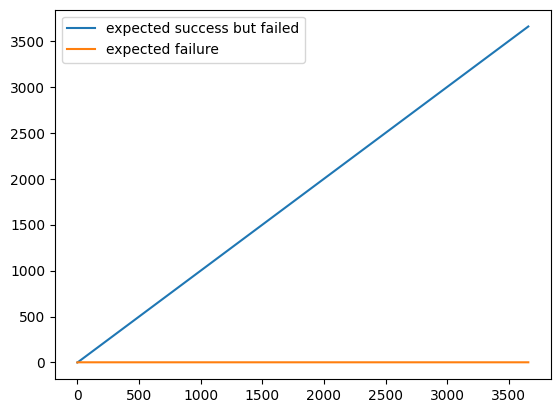

In [25]:
expected_success = np.array(reward_online) > FAIL_REWARD
feedback_success = np.array(reward_feedback) > FAIL_REWARD
expected_success_but_failed = expected_success * np.logical_not(feedback_success)
plt.plot(np.cumsum(expected_success_but_failed), label='expected success but failed')
plt.plot(np.cumsum(np.logical_not(expected_success)), label='expected failure')
plt.legend()
print("Num failures when expected success:", np.sum(expected_success_but_failed))

Regret: 0.0


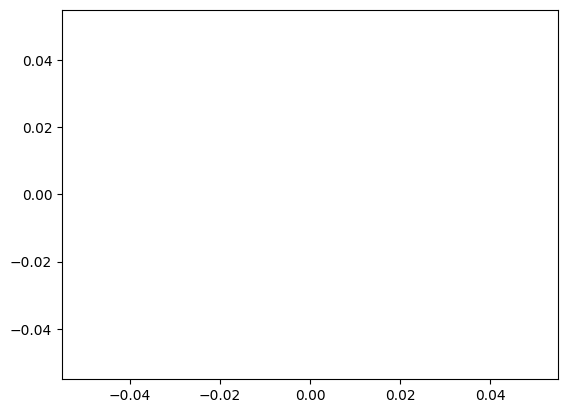

In [26]:
regret = np.subtract(reward_feedback, reward_offline)[feedback_success]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

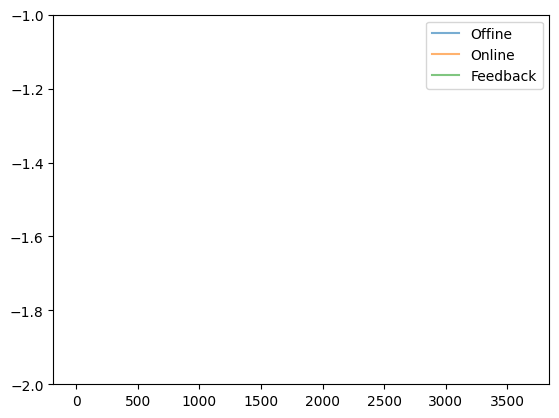

In [27]:
plt.plot(reward_offline, label='Offine', alpha=0.6)
plt.plot(reward_online, label='Online', alpha=0.6)
plt.plot(reward_feedback, label='Feedback', alpha=0.6)
plt.ylim(-2., -1)
plt.legend()

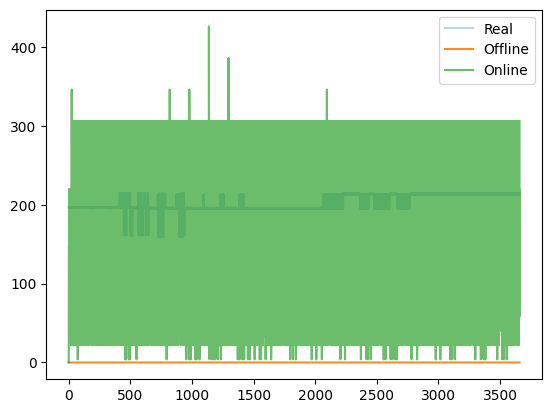

In [28]:
plt.plot(common_history.decision_idx[sep:], label='Real', alpha=0.3)
plt.plot(decisions_offline, label='Offline', alpha=0.9)
plt.plot(decisions_online, label='Online', alpha=0.7)
plt.legend()

<BarContainer object of 1 artists>

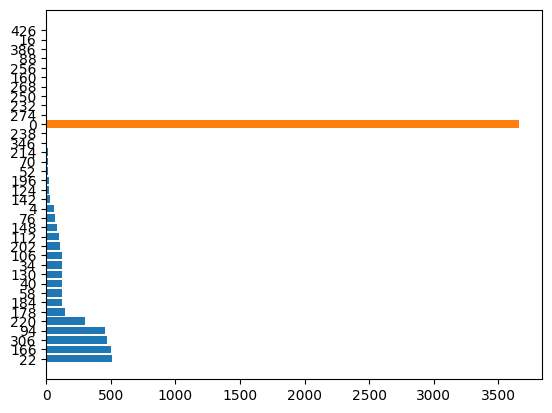

In [29]:
def count_decision_frequency(decisions, threshold=0):
    num_seleced = np.zeros(num_solvers)
    np.add.at(num_seleced, decisions, 1)
    frequent_solver_idx = np.argsort(num_seleced)[::-1]
    frequent_solver_idx = frequent_solver_idx[num_seleced[frequent_solver_idx] > threshold]
    return num_seleced, frequent_solver_idx

num_selected_offline, frequent_solver_idx_offline = count_decision_frequency(decisions_offline)
num_selected_online, frequent_solver_idx_online = count_decision_frequency(decisions_online)

plt.barh(frequent_solver_idx_online.astype(str), num_selected_online[frequent_solver_idx_online])
plt.barh(frequent_solver_idx_offline.astype(str), num_selected_offline[frequent_solver_idx_offline])

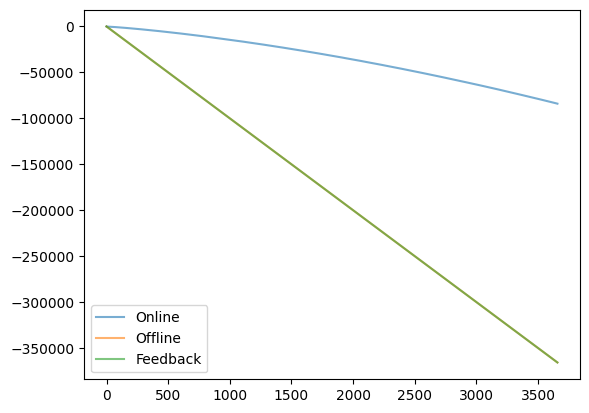

In [30]:
plt.plot(np.cumsum(reward_online), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(reward_feedback), label='Feedback', alpha=0.6)
# plt.plot(np.cumsum(common_history.reward[sep:]), label='Real', alpha=0.6)
plt.legend()

# How many times each solver was used?

array([945., 914., 833., 570., 361.,  20.,  16.,   8.])

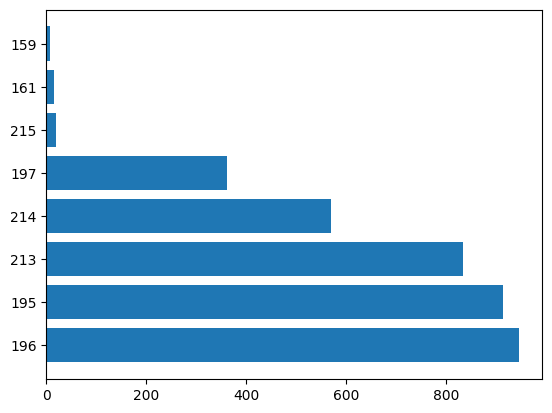

In [31]:
num_seleced, frequent_solver_idx = count_decision_frequency(common_history.decision_idx, threshold=1)

plt.barh(frequent_solver_idx.astype(str), num_seleced[frequent_solver_idx])
num_seleced[frequent_solver_idx]

/home/porepy/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/porepy/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


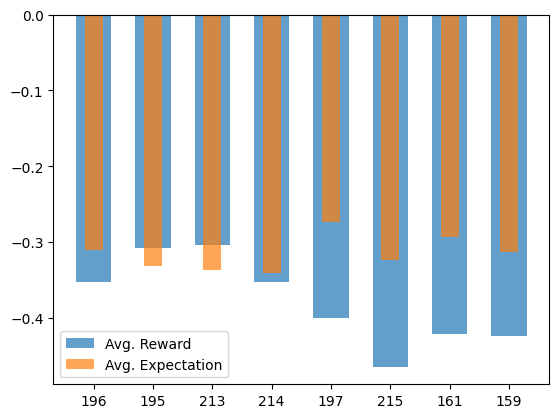

In [32]:
rewards_for_class = [[] for i in range(num_solvers)]
expectations_for_class = [[] for i in range(num_solvers)]


for reward, expectation, reward, solver_id in zip(y, common_history.expectation, common_history.reward, decision_id):
    if (-50 <= expectation <= 50 and -50 <= reward <= 50):
        rewards_for_class[solver_id].append(reward)
        expectations_for_class[solver_id].append(expectation)

avg_expectation_for_class = np.array([np.mean(x) for x in expectations_for_class])
avg_reward_for_class = np.array([np.mean(x) for x in rewards_for_class])

min_reward = -1
plt.bar(frequent_solver_idx.astype(str), avg_reward_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.6, label='Avg. Reward')
plt.bar(frequent_solver_idx.astype(str), avg_expectation_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.3, label='Avg. Expectation')
# plt.ylim(-2, 0.5)
plt.legend()

Transition matrix

In [33]:
from collections import defaultdict

category_to_idx = defaultdict(lambda: len(frequent_solver_idx)) | {x: i for i, x in enumerate(frequent_solver_idx)}
category_to_idx 

defaultdict(<function __main__.<lambda>()>,
            {196: 0, 195: 1, 213: 2, 214: 3, 197: 4, 215: 5, 161: 6, 159: 7})

In [34]:
M = np.zeros((frequent_solver_idx.size + 1, frequent_solver_idx.size + 1))
for a, b in zip(decision_id[:-1], decision_id[1:]):
    M[category_to_idx[a], category_to_idx[b]] += 1

P = M / M.sum(axis=1, keepdims=True)

Text(0.5, 1.0, 'P(next = (column) | current = (row))')

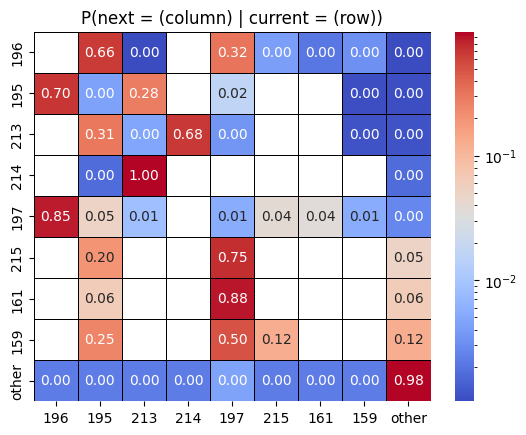

In [35]:
import seaborn as sns

labels = list(frequent_solver_idx.astype(str)) + ['other']

sns.heatmap(
    P,
    yticklabels=labels,
    xticklabels=labels,
    annot=True,
    fmt='.2f',
    norm="log",
    cmap="coolwarm",              # apply coolwarm palette
    linecolor="black",            # black grid lines
    linewidths=0.5                # line width > 0 to make lines visible
)
plt.title('P(next = (column) | current = (row))')

Assuming only one solver was allowed, what reward would we get if we chose system-AMG?

In [36]:
def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=RandomForestRegressor(criterion='squared_error', random_state=42))
regressor_offline.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape


reward_solvers = np.zeros((Xonline_features.shape[0], num_solvers))

for i, Xfeature in enumerate(Xonline_features[:]):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # offline
    predictions_offline = regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))
    reward_solvers[i] = predictions_offline
    

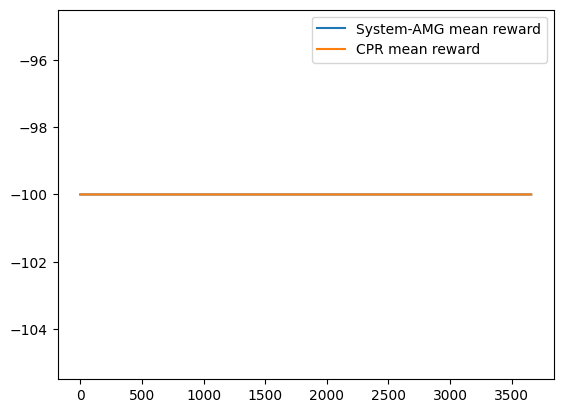

In [37]:
amg_rewards = reward_solvers[:, :123]
sorted_solver_ids = np.argsort(np.sum(amg_rewards,axis=0))[::-1][:110]  # 780
mean_amg_reward = np.mean(amg_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_amg_reward, label='System-AMG mean reward')

cpr_rewards = reward_solvers[:, 123:]
sorted_solver_ids = np.argsort(np.sum(cpr_rewards,axis=0))[::-1][:110]  # 780
mean_cpr_reward = np.mean(cpr_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_cpr_reward, label='CPR mean reward')

plt.legend()